In [117]:
import argparse
import pyscf
import ffsim
import numpy as np
import scipy
import sys

from functools import reduce
from itertools import product

sys.path.append("../")

from optimize import commutator_cost, variance_cost

In [2]:
molpath = "../hamiltonians/H4_linear_d2.0670.chk"

mol = pyscf.lib.chkfile.load_mol(molpath)
mf = pyscf.scf.RHF(mol)
mf.update_from_chk(molpath)
moldata = ffsim.MolecularData.from_scf(mf)

In [3]:
h_linop = ffsim.linear_operator(moldata.hamiltonian,
                                    norb=moldata.norb,
                                    nelec=moldata.nelec)

In [4]:
h_linop

<36x36 _CustomLinearOperator with dtype=complex128>

In [5]:
x = np.random.randn(moldata.norb * (moldata.norb - 1) // 2)

iu = np.triu_indices(moldata.norb, k=1)
rotation_generator = np.zeros((moldata.norb, moldata.norb))
rotation_generator[iu] = x
rotation_generator -= rotation_generator.T
U = scipy.linalg.expm(rotation_generator)

In [6]:
rotated_h = moldata.hamiltonian.rotated(U)

In [7]:
rotated_h_linop = ffsim.linear_operator(rotated_h,
                                    norb=moldata.norb,
                                    nelec=moldata.nelec)

In [8]:
e_0, v_0 = scipy.sparse.linalg.eigsh(h_linop, which="SA", k=1)
print(e_0)

[-1.89169532]


In [9]:
e_rotated, v_rotated = scipy.sparse.linalg.eigsh(rotated_h_linop, which="SA", k=1)
print(e_rotated)

[-1.89169532]


In [10]:
abs(v_rotated.T.conj() @ ffsim.apply_orbital_rotation(v_0, U, moldata.norb, moldata.nelec))

array([1.])

We need orbital seniority projectors or something like that. Then a subspace Hamiltonian will just be sandwiched between the projectors

In [11]:
def generalized_seniority_and_constant(i, a, b, c, d):
    return ffsim.FermionOperator(
                {
                    (ffsim.cre_a(i), ffsim.des_a(i)): a,
                    (ffsim.cre_b(i), ffsim.des_b(i)): b,
                    (ffsim.cre_a(i), ffsim.des_a(i), ffsim.cre_b(i), ffsim.des_b(i)): c,
                    (): d
                }
            )

In [12]:
generalized_seniority_and_constant(1, -1., -1., 1., 1.)

FermionOperator({
    (cre_b(1), des_b(1)): -1,
    (): 1,
    (cre_a(1), des_a(1)): -1,
    (cre_a(1), des_a(1), cre_b(1), des_b(1)): 1
})

By fixing $(a, b, c)$, we are partitioning the Hilbert space into subspaces based on populations of $n_{i \alpha}, n_{i \beta}$. There are 15 possible partitions, and all are attainable with some nonzero choices of $(a, b, c)$, except for the trivial partition which requires $a = b = c = 0$. Do I have to track 14 possible cases then?..

In [13]:
def distinct_generalized_seniority_sectors(a, b, c, atol=1e-3):
    sector_eigenvalues = [0, a, b, a + b + c]

    # https://stackoverflow.com/a/38924644/
    partitions = [] # Found partitions
    for i, e in enumerate(sector_eigenvalues): # Loop over each element
        found = False # Note it is not yet part of a known partition
        for p in partitions:
            if np.isclose(e, sector_eigenvalues[p[0]], atol=atol): # Found a partition for it!
                p.append(i)
                found = True
                break
        if not found: # Make a new partition for it.
            partitions.append([i])
    return partitions

In [14]:
def generalized_seniority_projectors(orbital_index, a, b, c):
    sectors = distinct_generalized_seniority_sectors(a, b, c)
    projectors = []
    for sector in sectors:
        operator = ffsim.FermionOperator({(): 0})
        for j in sector:
            if j == 0:
                operator += generalized_seniority_and_constant(orbital_index, -1, -1, 1, 1)
            elif j == 1:
                operator += generalized_seniority_and_constant(orbital_index, 1, 0, -1, 0)
            elif j == 2:
                operator += generalized_seniority_and_constant(orbital_index, 0, 1, -1, 0)
            elif j == 3:
                operator += generalized_seniority_and_constant(orbital_index, 0, 0, 1, 0)
            else:
                raise ValueError()
        projectors.append(operator)
    return projectors

In [41]:
ps = generalized_seniority_projectors(0, 1, 1, -2)

In [69]:
ffsim.linear_operator(ps[0], 4, (2, 2))

<36x36 _CustomLinearOperator with dtype=complex128>

In [71]:
ps[0]

FermionOperator({
    (cre_a(0), des_a(0)): -1,
    (cre_b(0), des_b(0)): -1,
    (): 1,
    (cre_a(0), des_a(0), cre_b(0), des_b(0)): 2
})

In [74]:
ffsim.linear_operator(ps[0], 4, (2, 2)) @ ffsim.linear_operator(ps[1], 4, (2, 2)) @ np.arange(1, 37)

array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j])

In [52]:
ffsim.linear_operator(ps[0], 1, 0) @ np.array([1])

array([1.+0.j])

In [46]:
ps[0]

FermionOperator({
    (cre_a(0), des_a(0)): -1,
    (cre_b(0), des_b(0)): -1,
    (): 1,
    (cre_a(0), des_a(0), cre_b(0), des_b(0)): 2
})

In [113]:
all_sectors = [distinct_generalized_seniority_sectors(1, 1, -2) for i in range(moldata.norb)]

sector_dimensions = [[len(w) for w in sector]
    for sector in all_sectors
]

all_projector_sets = [generalized_seniority_projectors(i, 1, 1, -2) for i in range(moldata.norb)]

In [112]:
sector_dimensions

[[2, 2], [2, 2], [2, 2], [2, 2]]

In [115]:
ffsim.linear_operator(all_projector_sets[2][0], 4, (2, 2)) @ np.arange(1, 37)

array([ 1.+0.j,  0.+0.j,  0.+0.j,  4.+0.j,  5.+0.j,  0.+0.j,  0.+0.j,
        8.+0.j,  9.+0.j,  0.+0.j,  0.+0.j, 12.+0.j,  0.+0.j, 14.+0.j,
       15.+0.j,  0.+0.j,  0.+0.j, 18.+0.j, 19.+0.j,  0.+0.j,  0.+0.j,
       22.+0.j, 23.+0.j,  0.+0.j, 25.+0.j,  0.+0.j,  0.+0.j, 28.+0.j,
       29.+0.j,  0.+0.j,  0.+0.j, 32.+0.j, 33.+0.j,  0.+0.j,  0.+0.j,
       36.+0.j])

In [116]:
lens = [len(p) for p in all_projector_sets]
print(lens)

[2, 2, 2, 2]


In [21]:
iterators = [range(q) for q in lens]

In [179]:
projected_eigenvectors = []
relevant_sector_indices = []

for i, w in enumerate(product(*iterators)):
    if np.sum(w) % 2 == 0:
        print(w)
        total_projector = ffsim.FermionOperator({(): 1})
        for orbital in range(moldata.norb):
            total_projector *= all_projector_sets[orbital][w[orbital]]
        total_projector_linop = ffsim.linear_operator(total_projector, moldata.norb, moldata.nelec)
        projected_h = total_projector_linop @ h_linop @ total_projector_linop
        
        dimension = 10
        sector_es, sector_vs = scipy.sparse.linalg.eigsh(projected_h, k=dimension, which="SA")
        print(sector_es)
        nonzero_eig_indices = np.where(sector_es < -1e-6)[0]
        print(nonzero_eig_indices)
        projected_eigenvectors.append((sector_es[nonzero_eig_indices], sector_vs[:, nonzero_eig_indices]))
        
        
        # projected_eigenvectors.append(scipy.sparse.linalg.eigsh(projected_h, k=dimension, which="SA"))
        relevant_sector_indices.append(i)

(0, 0, 0, 0)
[-6.06727928e-01 -1.66275437e+00 -1.54955494e+00 -1.14924496e+00
 -1.18969183e+00 -1.22287937e+00 -5.58781111e-29 -1.05990259e-32
 -4.64109875e-33 -2.04079595e-32]
[0 1 2 3 4 5]
(0, 0, 1, 1)
[-1.56335121e+00 -8.68145387e-01 -1.21216831e+00 -1.21932828e+00
 -5.89366482e-33 -4.87480096e-33 -3.33007182e-49 -4.59839772e-50
 -1.06116885e-49 -9.18329674e-49]
[0 1 2 3]
(0, 1, 0, 1)
[-1.55795433e+00 -9.48510002e-01 -1.29034320e+00 -1.21612114e+00
 -1.47548009e-31 -1.35981017e-32 -1.11258253e-34 -2.67874808e-55
 -2.80062608e-50 -1.23863451e-64]
[0 1 2 3]
(0, 1, 1, 0)
[-1.63271580e+00 -1.34050509e+00 -1.19957404e+00 -9.07363331e-01
 -1.03319528e-32 -1.99115101e-33 -8.00099261e-33 -4.73240881e-50
 -3.64017905e-49 -7.42911559e-65]
[0 1 2 3]
(1, 0, 0, 1)
[-9.85495148e-01 -1.55532150e+00 -1.23534888e+00 -1.30546777e+00
 -6.33694731e-33 -4.57750368e-34 -9.41297825e-49 -3.15236762e-49
 -3.10119249e-49 -2.38056550e-49]
[0 1 2 3]
(1, 0, 1, 0)
[-1.56916381e+00 -9.35788063e-01 -1.19506292e+00

In [180]:
[s[0] for s in projected_eigenvectors]

[array([-0.60672793, -1.66275437, -1.54955494, -1.14924496, -1.18969183,
        -1.22287937]),
 array([-1.56335121, -0.86814539, -1.21216831, -1.21932828]),
 array([-1.55795433, -0.94851   , -1.2903432 , -1.21612114]),
 array([-1.6327158 , -1.34050509, -1.19957404, -0.90736333]),
 array([-0.98549515, -1.5553215 , -1.23534888, -1.30546777]),
 array([-1.56916381, -0.93578806, -1.19506292, -1.30988895]),
 array([-1.56630744, -0.86009032, -1.19147127, -1.23492649]),
 array([-1.84539692, -0.89530434, -1.04397521, -1.31686812, -1.24446405,
        -1.22334429])]

In [181]:
relevant_sector_indices

[0, 3, 5, 6, 9, 10, 12, 15]

In [182]:
projected_eigenvectors[0][1][:, 0]

array([ 2.23234299e-01-7.17018157e-02j, -7.85062479e-32+3.09297446e-32j,
       -5.62893182e-18-1.07505507e-17j, -7.25190186e-18-1.12169971e-18j,
        1.14932459e-31-2.61315942e-32j,  1.02795491e-17+3.57755863e-17j,
        9.57574407e-33+4.75692038e-32j,  3.12497288e-01-1.00372671e-01j,
       -3.79377347e-32-2.57998848e-33j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        4.59131687e-18+5.80345023e-18j, -2.37567394e-32-1.28999424e-33j,
        3.94907931e-01-1.26842586e-01j,  0.00000000e+00+0.00000000e+00j,
       -2.07824831e-32-1.60825475e-32j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  4.19179543e-01-1.34638515e-01j,
        5.70819563e-31+9.84264559e-32j,  1.20571279e-17-4.81102859e-18j,
        0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
       -9.11203049e-33+4.75957060e-32j,  0.00000000

In [183]:
born_oppenheimer_collection = [s[1][:, 0] for s in projected_eigenvectors]

In [184]:
h_bo = np.zeros((len(born_oppenheimer_collection), len(born_oppenheimer_collection)), dtype="complex")

for i, j in product(range(len(born_oppenheimer_collection)), repeat=2):
    h_bo[i, j] = born_oppenheimer_collection[i].conj() @ h_linop @ born_oppenheimer_collection[j]

In [185]:
w_bo, v_bo = np.linalg.eigh(h_bo)

In [186]:
w_bo

array([-1.86027541, -1.84539692, -1.81176171, -1.56977999, -1.33231905,
       -1.31535643, -0.98549515, -0.60672793])

In [187]:
e_0

array([-1.89169532])

In [188]:
lowest_eigenvectors_pooled = np.concatenate([s[1] for s in projected_eigenvectors], axis=1)

In [189]:
lowest_eigenvectors_pooled.shape

(36, 36)

In [190]:
energies_pooled = np.concatenate([s[0] for s in projected_eigenvectors])

In [208]:
origins = []
for i, s in enumerate(projected_eigenvectors):
    origins.extend([i] * s[0].shape[0])
origins = np.array(origins, dtype=int)

In [196]:
overlaps_with_fci = (abs(lowest_eigenvectors_pooled.T.conj() @ v_0)**2).flatten()

In [230]:
overlaps_by_sector = np.zeros(len(relevant_sector_indices))
for i, x in enumerate(overlaps_with_fci):
    overlaps_by_sector[origins[i]] += x

In [232]:
print(overlaps_by_sector)

[7.78188271e-01 1.70359231e-27 2.42460525e-03 3.73965278e-28
 3.91365261e-28 2.98184234e-03 1.75122602e-27 2.16405281e-01]


In [197]:
sum(overlaps_with_fci)

1.0000000000000004

In [264]:
overlap_order_of_vectors = np.argsort(overlaps_with_fci)[::-1]

In [265]:
overlap_order_of_vectors

array([ 1, 31,  4, 32,  5,  0, 25, 12,  2, 23, 11,  3, 26,  6, 30, 19, 14,
       10, 22, 34, 28, 16, 24, 35,  9, 13, 20, 15,  8, 21, 29, 33, 27,  7,
       17, 18])

In [226]:
energies_pooled

array([-0.60672793, -1.66275437, -1.54955494, -1.14924496, -1.18969183,
       -1.22287937, -1.56335121, -0.86814539, -1.21216831, -1.21932828,
       -1.55795433, -0.94851   , -1.2903432 , -1.21612114, -1.6327158 ,
       -1.34050509, -1.19957404, -0.90736333, -0.98549515, -1.5553215 ,
       -1.23534888, -1.30546777, -1.56916381, -0.93578806, -1.19506292,
       -1.30988895, -1.56630744, -0.86009032, -1.19147127, -1.23492649,
       -1.84539692, -0.89530434, -1.04397521, -1.31686812, -1.24446405,
       -1.22334429])

In [238]:
energy_order_of_vectors = np.argsort(energies_pooled)

In [239]:
energy_order_of_vectors

array([30,  1, 14, 22, 26,  6, 10, 19,  2, 15, 33, 25, 21, 12, 34, 20, 29,
       35,  5,  9, 13,  8, 16, 24, 28,  4,  3, 32, 18, 11, 23, 17, 31,  7,
       27,  0])

In [240]:
energies_pooled[energy_order_of_vectors]

array([-1.84539692, -1.66275437, -1.6327158 , -1.56916381, -1.56630744,
       -1.56335121, -1.55795433, -1.5553215 , -1.54955494, -1.34050509,
       -1.31686812, -1.30988895, -1.30546777, -1.2903432 , -1.24446405,
       -1.23534888, -1.23492649, -1.22334429, -1.22287937, -1.21932828,
       -1.21612114, -1.21216831, -1.19957404, -1.19506292, -1.19147127,
       -1.18969183, -1.14924496, -1.04397521, -0.98549515, -0.94851   ,
       -0.93578806, -0.90736333, -0.89530434, -0.86814539, -0.86009032,
       -0.60672793])

In [228]:
origins[np.argsort(energies_pooled)]

array([7, 0, 3, 5, 6, 1, 2, 4, 0, 3, 7, 5, 4, 2, 7, 4, 6, 7, 0, 1, 2, 1,
       3, 5, 6, 0, 0, 7, 4, 2, 5, 3, 7, 1, 6, 0])

In [299]:
h_vecs_pooled = np.zeros((len(energies_pooled), len(energies_pooled)), dtype="complex")
inner_products = np.zeros_like(h_vecs_pooled)

for i, j in product(range(len(energies_pooled)), repeat=2):
    h_vecs_pooled[i, j] = lowest_eigenvectors_pooled[:, i].conj() @ h_linop @ lowest_eigenvectors_pooled[:, j]
    inner_products[i, j] = lowest_eigenvectors_pooled[:, i].conj() @ lowest_eigenvectors_pooled[:, j]

In [300]:
np.linalg.norm(inner_products - np.eye(len(energies_pooled)))

8.707012532432323e-14

In [301]:
np.sort(scipy.sparse.linalg.eigsh(h_linop, k=20, which="SA")[0])

array([-1.89169532, -1.87890861, -1.86526995, -1.85848205, -1.85143083,
       -1.84539692, -1.38807488, -1.37579827, -1.35991731, -1.34743228,
       -1.34621026, -1.33881841, -1.33781622, -1.32672815, -1.32236582,
       -1.31889211, -1.31314063, -1.30860196, -1.21152138, -1.20978003])

In [302]:
np.linalg.eigvalsh(h_vecs_pooled)

array([-1.89169532, -1.87890861, -1.86526995, -1.85848205, -1.85143083,
       -1.84539692, -1.38807488, -1.37579827, -1.35991731, -1.34743228,
       -1.34621026, -1.33881841, -1.33781622, -1.32672815, -1.32236582,
       -1.31889211, -1.31314063, -1.30860196, -1.21152138, -1.20978003,
       -1.2031988 , -1.20138766, -1.17186155, -1.16918135, -1.16804444,
       -1.16792971, -1.09344059, -1.09179682, -1.07216798, -1.07001626,
       -0.83020946, -0.82634141, -0.69276757, -0.67387911, -0.36105787,
       -0.36105707])

In [303]:
inner_products_with_fci = (lowest_eigenvectors_pooled.T.conj() @ v_0).flatten()

In [304]:
inner_products_with_fci.conj() @ h_vecs_pooled @ inner_products_with_fci.T

(-1.8916953153091784+2.220446049250313e-16j)

In [305]:
abs(np.linalg.eigh(h_vecs_pooled)[1][:, 0])**2

array([3.15768831e-03, 7.34805093e-01, 1.13336160e-03, 6.57808606e-04,
       3.50643042e-02, 3.37001492e-03, 2.97470459e-31, 1.25101952e-31,
       9.41226416e-31, 2.75260666e-34, 5.84190039e-29, 1.00375802e-03,
       1.42084723e-03, 5.79779187e-31, 1.03034690e-31, 7.30233077e-31,
       1.61459138e-33, 2.84432787e-32, 8.09299003e-35, 3.10058974e-34,
       3.84169018e-34, 6.31049246e-31, 5.42297125e-29, 1.12576062e-03,
       2.49163239e-30, 1.85608172e-03, 2.49113233e-31, 1.81832902e-31,
       8.69287255e-34, 4.97413058e-31, 7.74206659e-29, 1.93741730e-01,
       2.26635510e-02, 4.87743865e-31, 1.36114697e-29, 3.15429423e-30])

In [306]:
np.cumsum(np.sort(abs(np.linalg.eigh(h_vecs_pooled)[1][:, 0])**2)[::-1])

array([0.73480509, 0.92854682, 0.96361113, 0.98627468, 0.98964469,
       0.99280238, 0.99465846, 0.99607931, 0.99721267, 0.99833843,
       0.99934219, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        ])

In [307]:
subspace_sizes = np.arange(len(energies_pooled)) + 1
energies_by_energy_order = np.zeros_like(energies_pooled)
energies_by_overlap_order = np.zeros_like(energies_pooled)

In [308]:
for i in range(len(energies_pooled)):
    indices = overlap_order_of_vectors[:i + 1]
    h = h_vecs_pooled[:, indices][indices, :]
    # print(h.shape)
    energies_by_overlap_order[i] = np.linalg.eigvalsh(h)[0]
    # print(energies_by_overlap_order[i])
    
    indices = energy_order_of_vectors[:i + 1]
    h = h_vecs_pooled[:, indices][indices, :]
    # print(h.shape)
    energies_by_energy_order[i] = np.linalg.eigvalsh(h)[0]

    # if i > 15:
    #     break

In [309]:
np.diag(h_vecs_pooled.real)

array([-0.60672793, -1.66275437, -1.54955494, -1.14924496, -1.18969183,
       -1.22287937, -1.56335121, -0.86814539, -1.21216831, -1.21932828,
       -1.55795433, -0.94851   , -1.2903432 , -1.21612114, -1.6327158 ,
       -1.34050509, -1.19957404, -0.90736333, -0.98549515, -1.5553215 ,
       -1.23534888, -1.30546777, -1.56916381, -0.93578806, -1.19506292,
       -1.30988895, -1.56630744, -0.86009032, -1.19147127, -1.23492649,
       -1.84539692, -0.89530434, -1.04397521, -1.31686812, -1.24446405,
       -1.22334429])

In [310]:
energies_pooled

array([-0.60672793, -1.66275437, -1.54955494, -1.14924496, -1.18969183,
       -1.22287937, -1.56335121, -0.86814539, -1.21216831, -1.21932828,
       -1.55795433, -0.94851   , -1.2903432 , -1.21612114, -1.6327158 ,
       -1.34050509, -1.19957404, -0.90736333, -0.98549515, -1.5553215 ,
       -1.23534888, -1.30546777, -1.56916381, -0.93578806, -1.19506292,
       -1.30988895, -1.56630744, -0.86009032, -1.19147127, -1.23492649,
       -1.84539692, -0.89530434, -1.04397521, -1.31686812, -1.24446405,
       -1.22334429])

In [311]:
import matplotlib.pyplot as plt

(1e-06, 1)

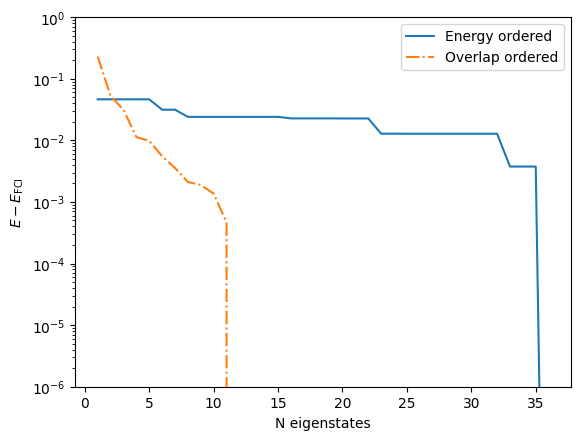

In [315]:
plt.plot(subspace_sizes, energies_by_energy_order - e_0, label="Energy ordered")
plt.plot(subspace_sizes, energies_by_overlap_order - e_0, "-.", label="Overlap ordered")
plt.yscale("log")
# plt.axhline(0.0016, linestyle="--", color="tab:red")
plt.xlabel("N eigenstates")
plt.ylabel(r"$E - E_{\mathrm{FCI}}$")
plt.legend()
plt.ylim([1e-6, 1])

In [277]:
overlaps_with_fci[overlap_order_of_vectors]

array([7.34805093e-01, 1.93741730e-01, 3.50643042e-02, 2.26635510e-02,
       3.37001492e-03, 3.15768831e-03, 1.85608172e-03, 1.42084723e-03,
       1.13336160e-03, 1.12576062e-03, 1.00375802e-03, 6.57808606e-04,
       1.74260263e-27, 1.69870315e-27, 6.38950908e-28, 3.88998464e-28,
       3.66074660e-28, 1.61591749e-28, 1.48361449e-28, 1.82740418e-29,
       8.00925292e-30, 6.94515019e-30, 6.35545006e-30, 4.67923939e-30,
       4.06973034e-30, 3.77987299e-30, 1.67994737e-30, 9.19767918e-31,
       7.28321219e-31, 6.85055528e-31, 4.78300070e-31, 1.66556829e-31,
       1.35837620e-31, 9.11089926e-32, 2.56996156e-32, 1.79480494e-33])

In [276]:
np.sort(overlaps_with_fci)[::-1]

array([7.34805093e-01, 1.93741730e-01, 3.50643042e-02, 2.26635510e-02,
       3.37001492e-03, 3.15768831e-03, 1.85608172e-03, 1.42084723e-03,
       1.13336160e-03, 1.12576062e-03, 1.00375802e-03, 6.57808606e-04,
       1.74260263e-27, 1.69870315e-27, 6.38950908e-28, 3.88998464e-28,
       3.66074660e-28, 1.61591749e-28, 1.48361449e-28, 1.82740418e-29,
       8.00925292e-30, 6.94515019e-30, 6.35545006e-30, 4.67923939e-30,
       4.06973034e-30, 3.77987299e-30, 1.67994737e-30, 9.19767918e-31,
       7.28321219e-31, 6.85055528e-31, 4.78300070e-31, 1.66556829e-31,
       1.35837620e-31, 9.11089926e-32, 2.56996156e-32, 1.79480494e-33])

In [199]:
cdf = np.cumsum(np.sort(overlaps_with_fci)[::-1])

In [200]:
cdf

array([0.73480509, 0.92854682, 0.96361113, 0.98627468, 0.98964469,
       0.99280238, 0.99465846, 0.99607931, 0.99721267, 0.99833843,
       0.99934219, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        ])

In [204]:
n_states_to_fidelity = min(np.where(cdf > 0.99)[0])
print(n_states_to_fidelity)

5


In [221]:
origins[np.argsort(overlaps_with_fci)[::-1]]

array([0, 7, 0, 7, 0, 0, 5, 2, 0, 5, 2, 0, 6, 1, 7, 4, 3, 2, 5, 7, 6, 3,
       5, 7, 1, 2, 4, 3, 1, 4, 6, 7, 6, 1, 3, 4])

In [216]:
sector_labels = list(product(*iterators))

In [222]:
print(sector_labels[relevant_sector_indices[0]], 
      sector_labels[relevant_sector_indices[7]],
      sector_labels[relevant_sector_indices[5]])

(0, 0, 0, 0) (1, 1, 1, 1) (1, 0, 1, 0)


In [223]:
[(j, sector_labels[relevant_sector_indices[j]]) for j in range(len(relevant_sector_indices))]

[(0, (0, 0, 0, 0)),
 (1, (0, 0, 1, 1)),
 (2, (0, 1, 0, 1)),
 (3, (0, 1, 1, 0)),
 (4, (1, 0, 0, 1)),
 (5, (1, 0, 1, 0)),
 (6, (1, 1, 0, 0)),
 (7, (1, 1, 1, 1))]